In [1]:
%%capture
! pip install shapely laspy 

In [2]:
# Geospatial and mapping libraries
import geopandas as gpd

# LAS (LiDAR) file handling
import laspy
from laspy import read

# Data analysis and manipulation
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# Warnings management
import warnings

import os
import itertools


# Return type hints
from typing import Tuple, List, Union, Generator


from scipy.spatial import KDTree
import scipy

import collections

import shapely



In [3]:
def load_las_file(file_path: str) -> laspy.LasData:
    """
    Load a .las file and return the full laspy.LasData object.
    """
    try:
        las = laspy.read(file_path)
        return las  
    except Exception as e:
        print(f"Error loading file: {e}")
        return None


In [4]:
def shift_points_to_origin(points) -> np.ndarray:
    """
    Shift points to the origin (0, 0, 0) by subtracting the minimum coordinates.
    """
    return points - points.min(axis=0, keepdims=True)

In [5]:
def plot_shifted_lidar(lidar_file: str):
    """
    Plot a 3D LiDAR point cloud with ground points in red. Coordinates are shifted for better visualization.
    """
    try:
        las = laspy.read(lidar_file)
        points = np.stack([las.x, las.y, las.z], axis=1)
        classifications = las.classification

        # shift points to start from (0, 0, 0)
        points = shift_points_to_origin(points)
        ground_mask = classifications == 2
        ground_points = points[ground_mask]
        other_points = points[~ground_mask]

        file_name = os.path.splitext(os.path.basename(lidar_file))[0]

        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection="3d")

        ax.scatter(
            ground_points[:, 0],
            ground_points[:, 1],
            ground_points[:, 2],
            c="red",
            s=0.5,
            label="Ground Points",
        )

        ax.scatter(
            other_points[:, 0],
            other_points[:, 1],
            other_points[:, 2],
            c=other_points[:, 2],
            cmap="viridis",
            s=0.5,
        )

        ax.set_title("LiDAR Point Cloud Visualization (Shifted)")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")  

        ax.view_init(elev=30, azim=45)  
        ax.legend(loc="upper right", markerscale=5, fontsize=10)

        plt.figtext(0.5, 0.01, f"{file_name}", ha="center", style="italic")

        plt.show()

    except Exception as e:
        print(f"Error visualizing LiDAR file: {e}")


In [6]:
def calculate_iqr_outliers(z_values: np.ndarray) -> Tuple[float, float]:
    """
    Calculate the lower and upper bounds for outliers in Z values based on the IQR method.
    """
    q1 = np.percentile(z_values, 25)  # 25th percentile (Q1)
    q3 = np.percentile(z_values, 75)  # 75th percentile (Q3)
    iqr = q3 - q1  # Interquartile range (IQR)
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    return lower_bound, upper_bound


In [7]:
def plot_z_distribution(z_values: np.ndarray, ax, file_name: str):
    """
    Plot the Z-value distribution for the given z-values on a specific subplot, with outlier boundaries.
    """
    lower_bound, upper_bound = calculate_iqr_outliers(z_values)
    
    # Plot histogram
    ax.hist(z_values, bins=50, color="green", alpha=0.7, label="Z Values")
    
    # Add IQR outlier lines
    ax.axvline(lower_bound, color="red", linestyle="--", label=f"Lower: {lower_bound:.2f}")
    ax.axvline(upper_bound, color="red", linestyle="--", label=f"Upper: {upper_bound:.2f}")
    
    ax.set_title(file_name, fontsize=10)
    ax.set_xlabel("Z Value (Height)", fontsize=8)
    ax.set_ylabel("Frequency", fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)


In [8]:
LAS_GROUND_CLASS = 2

def normalize_cloud_height(las):
    out = las.xyz.copy()
    assert np.any(las.classification == LAS_GROUND_CLASS)
    ground_level = scipy.interpolate.griddata(
        points=las.xyz[las.classification == LAS_GROUND_CLASS, :2],
        values=las.xyz[las.classification == LAS_GROUND_CLASS, 2],
        xi=las.xyz[:, :2],
        method="nearest",
    )
    out[:, 2] -= ground_level
    return out

In [9]:
def preprocess_data(las) -> np.ndarray:
    """
    Preprocess LiDAR points by normalizing heights relative to ground and removing outliers.
    """
    normalized_cloud = normalize_cloud_height(las)
    
    z_values = normalized_cloud[:, 2]
    lower_bound, upper_bound = calculate_iqr_outliers(z_values)
    mask = (z_values >= lower_bound) & (z_values <= upper_bound)
    
    filtered_points = normalized_cloud[mask]
    
    return filtered_points


In [10]:
def split_dataset(data: List, train_ratio: float = 0.7) -> Tuple[List, List]:
    """
    Splits the dataset into training and testing sets based on the given ratio.
    """
    split_idx = int(len(data) * train_ratio)
    
    train_data = data[:split_idx]
    test_data = data[split_idx:]
    
    return train_data, test_data

In [11]:
def local_maxima_filter(cloud: np.ndarray, window_size: float, height_threshold: float) -> np.ndarray:
    """Detect local maxima in the point cloud with a fixed window size."""
    
    assert isinstance(cloud, np.ndarray), f"Cloud needs to be a numpy array, not {type(cloud)}"
    
    cloud = cloud[cloud[:, 2] > height_threshold]
    tree = KDTree(data=cloud)
    seen_mask = np.zeros(cloud.shape[0], dtype=bool)
    local_maxima = []

    for i, point in enumerate(cloud):
        if seen_mask[i]:
            continue
        neighbor_indices = tree.query_ball_point(point, window_size)
        highest_neighbor = neighbor_indices[cloud[neighbor_indices, 2].argmax()]
        seen_mask[neighbor_indices] = True
        seen_mask[highest_neighbor] = False 
        # This may lead to not every point being marked as seen in the end, but it does not matter,
        # because by the time the seen value is overwritten the point is already processed
        if i == highest_neighbor:
            local_maxima.append(i)
    return cloud[local_maxima]

In [12]:
def _ndarray_to_tuple(array: np.ndarray) -> tuple:
    """Convert an array to a tuple, replacing np.nan with None."""
    return tuple(None if np.isnan(x) else x for x in array)

In [13]:
def match_candidates(
    ground_truth: np.ndarray,
    candidates: np.ndarray,
    *,
    max_distance: float,
    max_height_difference: float,
) -> list[dict]:
    """Match ground truth trees to candidates.
    """

    distance_matrix = scipy.spatial.distance_matrix(
        x=ground_truth[:, :2],
        y=candidates[:, :2],
    )
    indices = np.nonzero(distance_matrix <= max_distance)  # (ground_truths, candidates)
    distances = distance_matrix[indices]
    sparse_distances = sorted((d, pair) for d, pair in zip(distances, zip(*indices)))

    ground_truth_matched_mask = np.zeros(ground_truth.shape[0], dtype=bool)
    candidates_matched_mask = np.zeros(candidates.shape[0], dtype=bool)
    out = []

    for distance, (i, j) in sparse_distances:
        if ground_truth_matched_mask[i] and candidates_matched_mask[j]:
            continue

        if (
            not np.isnan(ground_truth[i][2])
            and abs(ground_truth[i][2] - candidates[j][2]) > max_height_difference
        ):
            continue

        if ground_truth_matched_mask[i]:
            candidates_matched_mask[j] = True
            out.append(
                {
                    "ground_truth": None,
                    "candidate": _ndarray_to_tuple(candidates[j]),
                    "class": "FP",
                    "distance": None,
                }
            )
        elif candidates_matched_mask[j]:
            ground_truth_matched_mask[i] = True
            out.append(
                {
                    "ground_truth": _ndarray_to_tuple(ground_truth[i]),
                    "candidate": None,
                    "class": "FN",
                    "distance": None,
                }
            )
        else:
            ground_truth_matched_mask[i] = True
            candidates_matched_mask[j] = True
            out.append(
                {
                    "ground_truth": _ndarray_to_tuple(ground_truth[i]),
                    "candidate": _ndarray_to_tuple(candidates[j]),
                    "class": "TP",
                    "distance": distance,
                }
            )

    out.extend(
        {
            "ground_truth": _ndarray_to_tuple(point),
            "candidate": None,
            "class": "FN",
            "distance": None,
        }
        for point in ground_truth[~ground_truth_matched_mask]
    )

    out.extend(
        {
            "ground_truth": None,
            "candidate": tuple(point),
            "class": "FP",
            "distance": None,
        }
        for point in candidates[~candidates_matched_mask]
    )

    return out

In [15]:
def extract_points_from_matches(matches: dict) -> Generator[dict, None, None]:
    for match in matches:
        if match["ground_truth"] is not None:
            yield {
                "geometry": shapely.Point(match["ground_truth"][:2]),
                "class": "TP_gt" if match["class"] == "TP" else match["class"],
                "height": match["ground_truth"][2],
            }
        if match["candidate"] is not None:
            yield {
                "geometry": shapely.Point(match["candidate"][:2]),
                "class": "TP" if match["class"] == "TP" else match["class"],
                "height": match["candidate"][2],
            }

In [16]:
def crop_by_other(points: np.ndarray, other: np.ndarray) -> np.ndarray:
    """Crop points by the extent of other."""
    hull = scipy.spatial.ConvexHull(other[:, :2])
    vertex_points = hull.points[hull.vertices]
    delaunay = scipy.spatial.Delaunay(vertex_points)
    within_hull = delaunay.find_simplex(points[:, :2]) >= 0
    return points[within_hull]

In [17]:
def calculate_metrics(group):
    classes = collections.Counter(group["class"])
    metrics = {
        "recall": classes["TP"] / (classes["TP"] + classes["FN"]),
        "precision": classes["TP"] / (classes["TP"] + classes["FP"]),
    }
    if metrics["recall"] + metrics["precision"] > 0:
        metrics["f1"] = 2 * metrics["recall"] * metrics["precision"]
        metrics["f1"] = metrics["f1"] / (metrics["recall"] + metrics["precision"])
    else:
        metrics["f1"] = 0
    metrics["avg_dist"] = group["distance"].mean()
    return round(pd.Series(metrics), 2)

In [18]:
plot_las_files = [f"../data/als/plot_{i:02d}.las" for i in range(1, 11)]

### Preprocessing

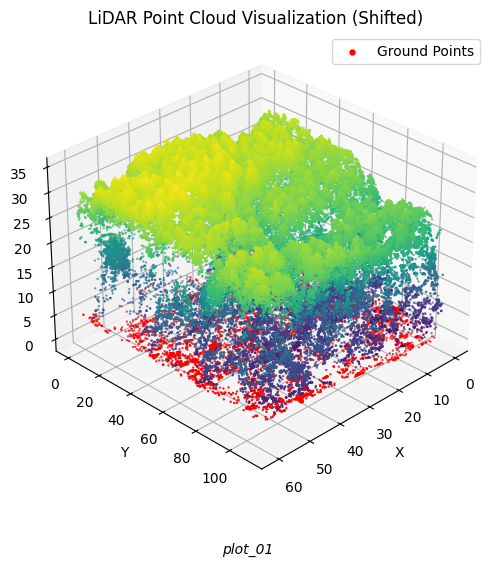

In [19]:
plot_shifted_lidar(plot_las_files[0])

Processing plot_01.las...
Processing plot_02.las...
Processing plot_03.las...
Processing plot_04.las...
Processing plot_05.las...
Processing plot_06.las...
Processing plot_07.las...
Processing plot_08.las...
Processing plot_09.las...
Processing plot_10.las...


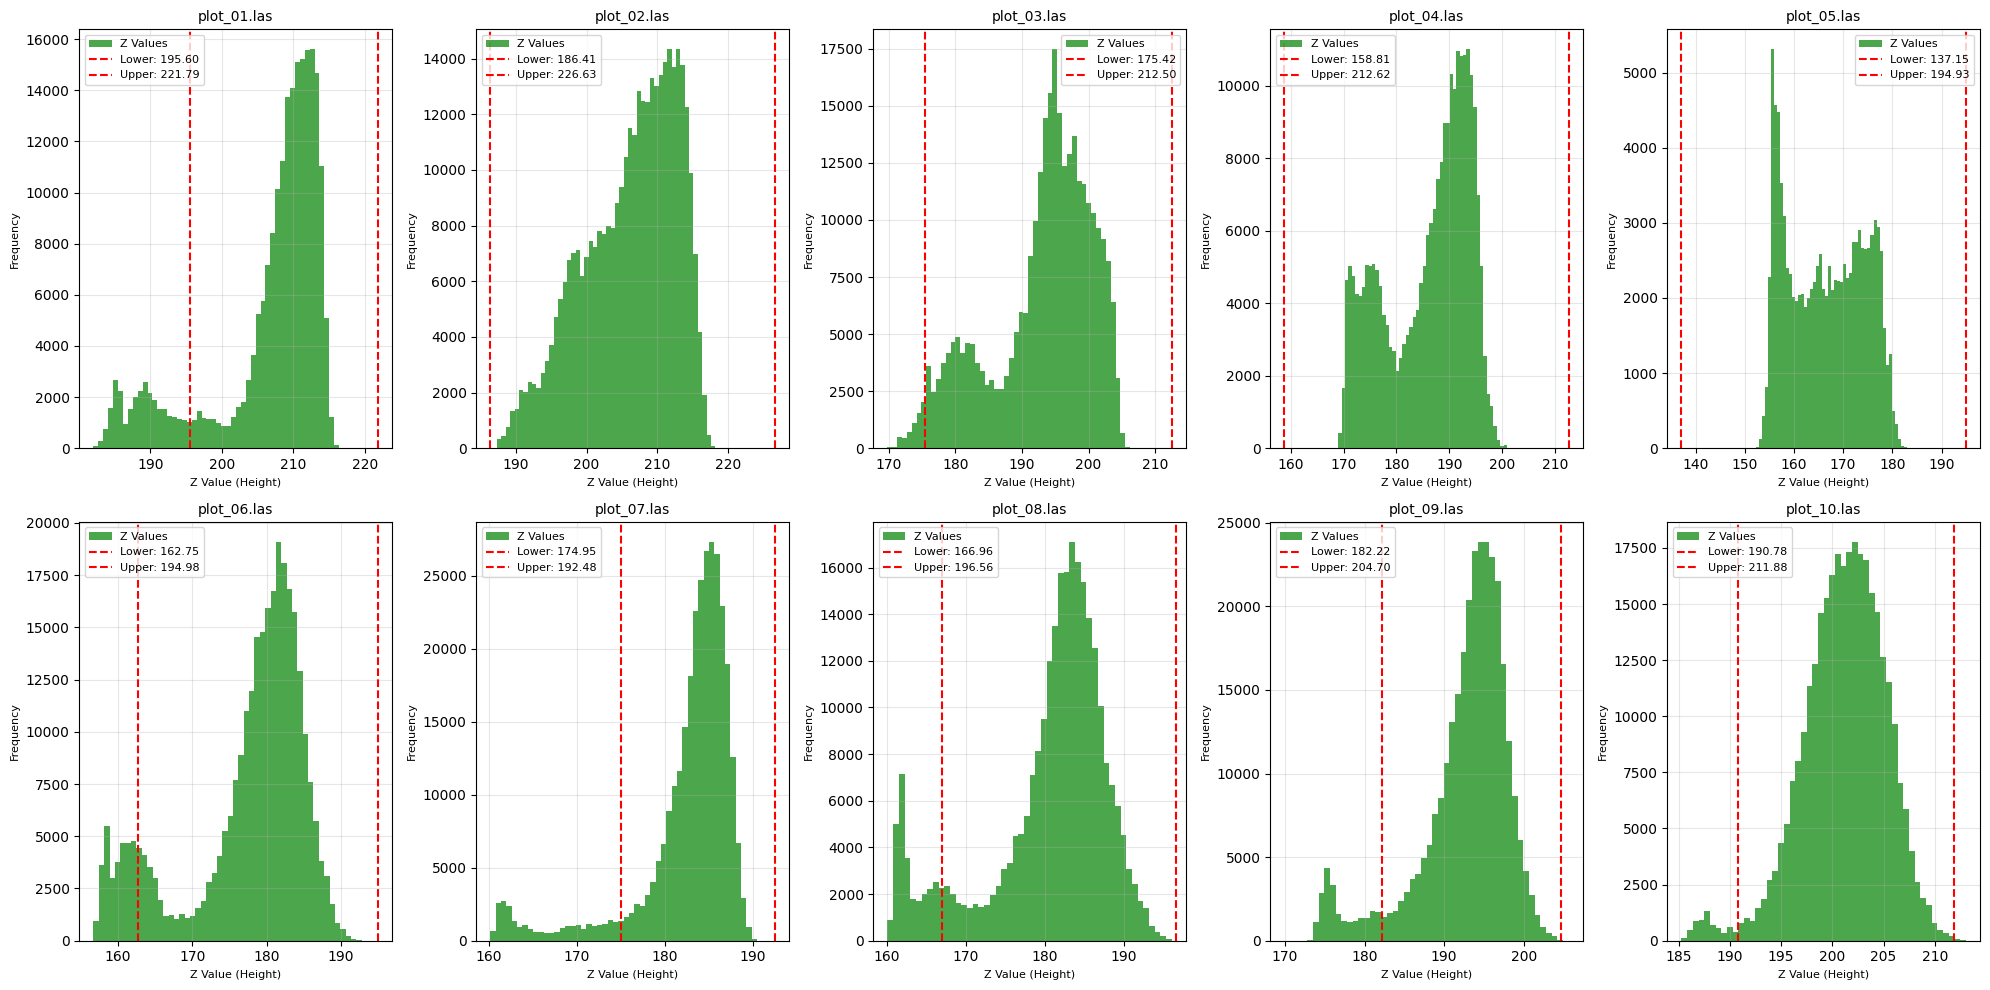

In [20]:
fig, axes = plt.subplots(2, 5, figsize=(20, 10))  
axes = axes.flatten()  

for i, file_path in enumerate(plot_las_files[:10]):  
    file_name = os.path.basename(file_path)
    print(f"Processing {file_name}...")
    
    las = load_las_file(file_path)
    if las is None or len(las.x) == 0:  
        print(f"Skipping {file_name} due to an error or no valid points.")
        continue
    
    plot_z_distribution(las.z, axes[i], file_name)

plt.tight_layout()
plt.show()


In [21]:
field_survey_gpd = gpd.read_file("../data/field_survey.geojson")
field_survey_gpd["coords"] = field_survey_gpd.get_coordinates().apply(
    lambda x: (x["x"], x["y"]),
    axis=1,
)

In [22]:
preprocessed_data = []  

for file_path in plot_las_files:
    
    las = load_las_file(file_path)  
    
    if las is not None and len(las.x) > 0:  
        preprocessed_points = preprocess_data(las)  
        preprocessed_data.append(preprocessed_points)  
    else:
        print(f"Skipping {file_path} due to no valid points.")

for i, points in enumerate(preprocessed_data):
    print(f"File {i + 1}: {len(points)} preprocessed points")


File 1: 186897 preprocessed points
File 2: 355599 preprocessed points
File 3: 282788 preprocessed points
File 4: 251251 preprocessed points
File 5: 105771 preprocessed points
File 6: 263587 preprocessed points
File 7: 284775 preprocessed points
File 8: 240625 preprocessed points
File 9: 289525 preprocessed points
File 10: 307468 preprocessed points


### Split data into train and test

In [23]:
train_ratio = 0.7
train_data, test_data = split_dataset(preprocessed_data, train_ratio)

### Detection Method

#### Local Maxima Filtering Algorithm

In [26]:
window_size = 3  # Radius for neighbor search
height_threshold = 2  # Minimum height to consider

for i, points in enumerate(preprocessed_data):
    local_maxima_points = local_maxima_filter(points, window_size, height_threshold)
    print(f"Detected {len(local_maxima_points)} local maxima in training file {i + 1}.")
    


Detected 236 local maxima in training file 1.
Detected 159 local maxima in training file 2.
Detected 248 local maxima in training file 3.
Detected 189 local maxima in training file 4.
Detected 221 local maxima in training file 5.
Detected 301 local maxima in training file 6.
Detected 160 local maxima in training file 7.
Detected 244 local maxima in training file 8.
Detected 186 local maxima in training file 9.
Detected 165 local maxima in training file 10.


In [27]:
%%time

raw_matches = {}
results = {}

for file in plot_las_files:
    plot = int(os.path.basename(file).split("_")[-1].split(".")[0])
    
    las = load_las_file(file)
    cloud = normalize_cloud_height(las)
    
    # Filter ground truth data for this plot
    subset = field_survey_gpd.query(f"plot == {plot}")
    ground_truth = subset.get_coordinates().to_numpy()
    ground_truth = np.hstack([ground_truth, subset["height"].to_numpy()[:, None]])
    
    # Detect local maxima
    candidates = local_maxima_filter(
        cloud=cloud,
        window_size=2,
        height_threshold=3,
    )
    
    # Crop candidates to match the ground truth area
    candidates = crop_by_other(candidates, ground_truth)
    
    # Match candidates to ground truth
    matches = match_candidates(
        ground_truth=ground_truth,
        candidates=candidates,
        max_distance=5,
        max_height_difference=3,
    )
    
    # Store raw matches
    raw_matches[file] = matches
    
    # Normalize matches into a DataFrame
    matches = pd.json_normalize(matches)
    matches["coords"] = matches["ground_truth"].map(lambda x: x if x is None else x[:2])
    
    # Merge with ground truth data
    results[file] = pd.merge(
        left=subset.drop(columns=["d1", "d2"]),
        right=matches[["candidate", "class", "distance", "coords"]],
        on="coords",
        how="outer",
    )
    results[file]["plot"] = plot


CPU times: total: 3.2 s
Wall time: 11 s


In [29]:
lines_dfs = []
points_dfs = []

for file_path, matches in raw_matches.items():
    # Extract plot number from file path
    plot = int(os.path.basename(file_path).split("_")[-1].split(".")[0])

    # Create GeoDataFrame for points
    points = gpd.GeoDataFrame(extract_points_from_matches(matches), crs=32640)
    points["plot"] = plot
    points_dfs.append(points)

    # Create GeoSeries for lines
    lines = gpd.GeoSeries(
        data=[
            shapely.LineString([m["ground_truth"][:2], m["candidate"][:2]])
            for m in matches
            if m["class"] == "TP"
        ],
        crs=32640,
    )
    lines = lines.to_frame(name="geometry")
    lines["plot"] = plot
    lines_dfs.append(lines)


In [30]:
all_points = pd.concat(points_dfs)
all_lines = pd.concat(lines_dfs)

all_points.to_file("../results/detection_results_points.geojson")
all_lines.to_file("../results/detection_results_lines.geojson")

In [31]:
all_results = pd.concat(results.values())
all_results.query("distance.notnull()").head(n=10)

,plot,tree_no,species,dbh,age,height,angle,comment,geometry,coords,candidate,class,distance
3,1,340.0,Aspen,27.90,NaN,NaN,0.0,None,POINT (547072.854 6450351.849),"(547072.854, 6450351.849)","(547073.335, 6450352.8393, 29.093999999999994)",TP,1.100934
5,1,342.0,Aspen,27.55,NaN,NaN,0.0,None,POINT (547073.094 6450339.845),"(547073.094, 6450339.84499999)","(547072.55, 6450341.3403, 5.828000000000003)",TP,1.591181
6,1,341.0,Aspen,32.50,88.0,32.2,0.0,None,POINT (547073.467 6450340.915),"(547073.466999999, 6450340.915)","(547073.853, 6450341.2953, 30.318000000000012)",TP,0.541871
11,1,345.0,Aspen,26.55,NaN,NaN,0.0,None,POINT (547074.184 6450336.833),"(547074.184, 6450336.83299999)","(547073.569, 6450337.2053, 16.254999999999995)",TP,0.718910
13,1,240.0,Fir,12.20,NaN,NaN,0.0,None,POINT (547074.43 6450371.61),"(547074.43, 6450371.61)","(547074.062, 6450372.0243, 8.22399999999999)",TP,0.554138
14,1,161.0,Aspen,22.35,NaN,NaN,0.0,None,POINT (547074.462 6450386.707),"(547074.462, 6450386.707)","(547073.359, 6450385.8423, 17.385999999999996)",TP,1.401540
15,1,91.0,Fir,26.20,NaN,NaN,0.0,None,POINT (547074.581 6450403.037),"(547074.581, 6450403.03699999)","(547073.993, 6450403.3593, 25.72)",TP,0.670538
16,1,166.0,Aspen,28.80,79.0,29.7,0.0,None,POINT (547074.617 6450374.97),"(547074.616999999, 6450374.96999999)","(547074.353, 6450374.7473, 27.738)",TP,0.345386
17,1,5.0,Aspen,27.25,NaN,NaN,0.0,None,POINT (547074.669 6450415.573),"(547074.668999999, 6450415.57299999)","(547074.525, 6450414.0223, 26.752999999999986)",TP,1.557372
18,1,165.0,Birch,13.80,NaN,NaN,0.0,None,POINT (547074.779 6450376.124),"(547074.778999999, 6450376.12399999)","(547074.451, 6450375.6953, 14.046999999999997)",TP,0.539785


In [32]:
metrics = all_results.groupby("plot").apply(calculate_metrics, include_groups=False)
metrics

,recall,precision,f1,avg_dist
plot,,,,
1,0.69,0.45,0.54,0.73
2,0.48,0.56,0.52,0.79
3,0.62,0.40,0.48,1.08
4,0.56,0.38,0.46,1.04
5,0.65,0.45,0.53,1.02
6,0.61,0.36,0.45,0.80
7,0.59,0.45,0.51,0.89
8,0.65,0.39,0.48,0.82
9,0.48,0.59,0.53,0.98


In [33]:
print("\nAverage metrics across all plots:")
print(metrics.mean(numeric_only=True))



Average metrics across all plots:
recall       0.571
precision    0.478
f1           0.501
avg_dist     0.893
dtype: float64


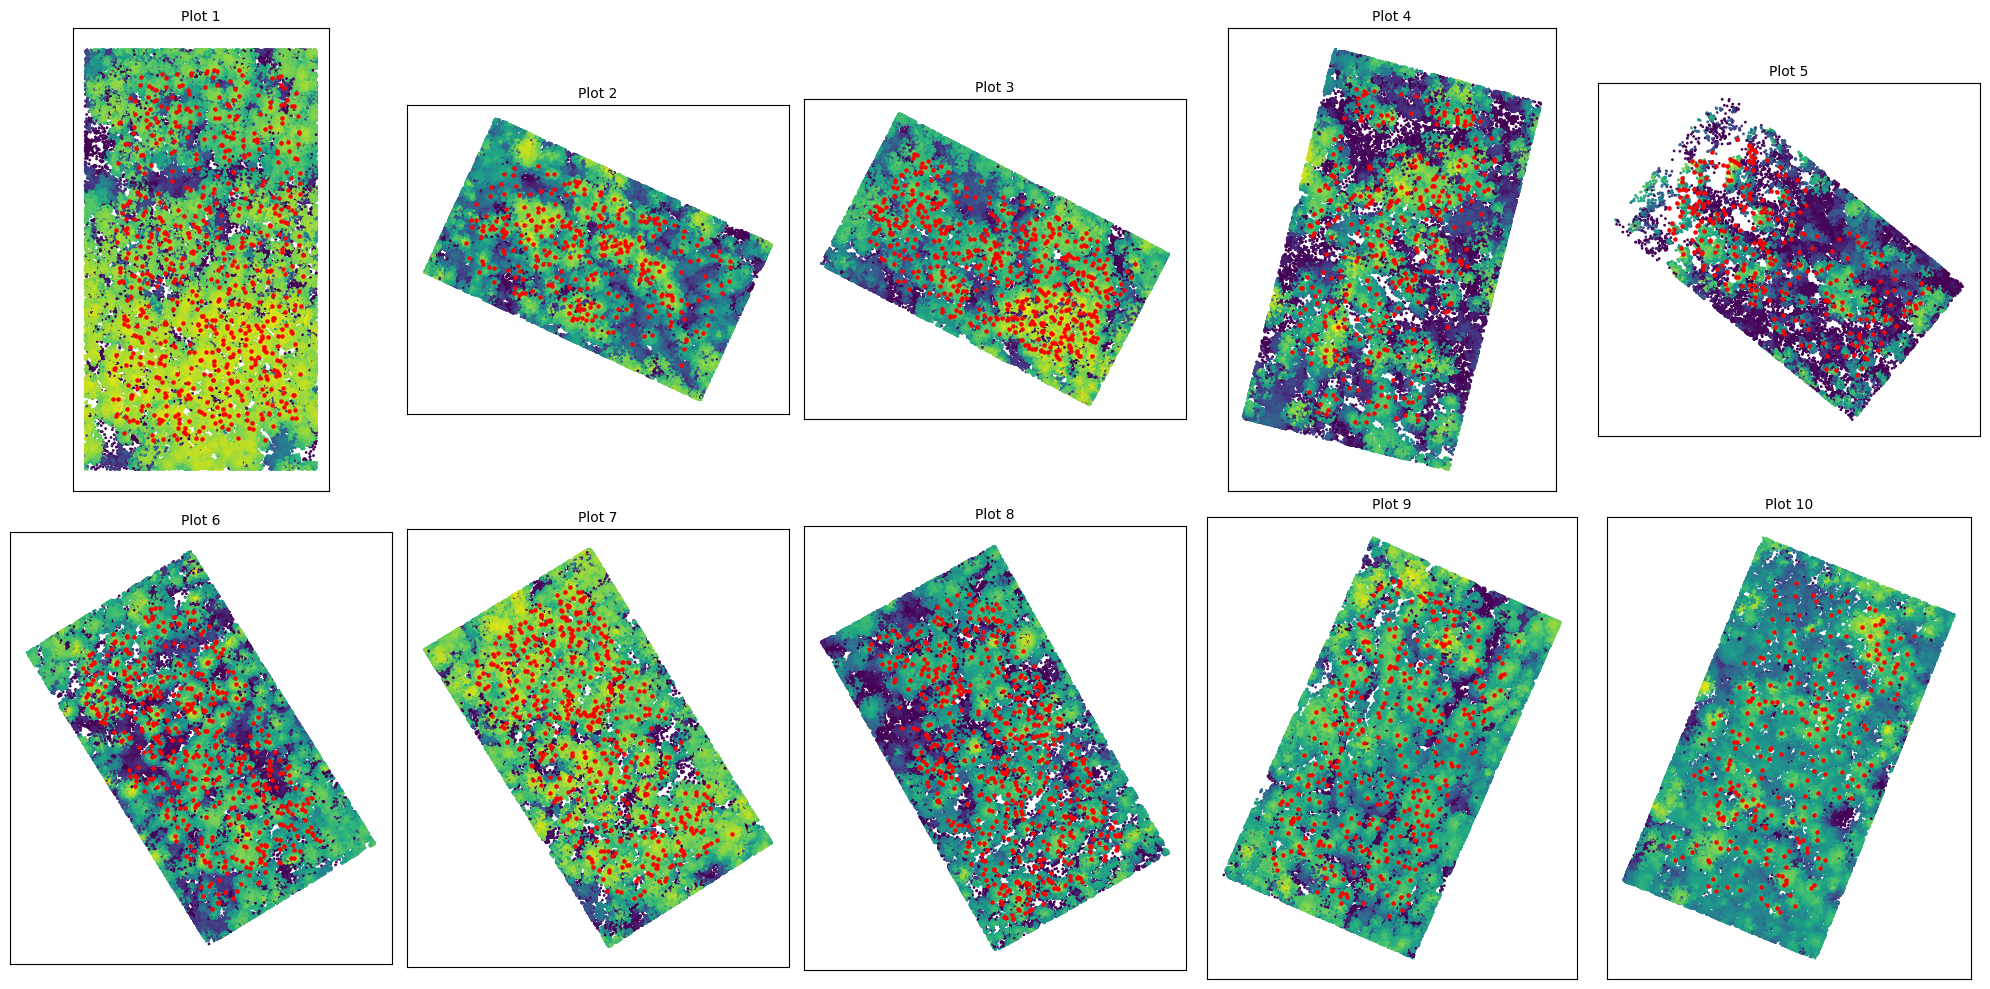

In [40]:
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for idx, (file_path, matches) in enumerate(raw_matches.items()):
    plot = int(os.path.basename(file_path).split("_")[-1].split(".")[0])

    las = load_las_file(file_path)
    cloud = normalize_cloud_height(las)  
    local_maxima = np.array([
        m["candidate"] for m in matches if m["class"] in ["TP", "FP"]
    ])

    ax = axes[idx]

    sc = ax.scatter(cloud[:, 0], cloud[:, 1], c=cloud[:, 2], s=1, cmap="viridis")
    
    # Plot local maxima in red
    if len(local_maxima) > 0:
        ax.scatter(local_maxima[:, 0], local_maxima[:, 1], c="red", s=5, label="Local Maxima")
    
    ax.set_title(f"Plot {plot}", fontsize=10)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])


plt.tight_layout()
plt.show()


#### Convert Point Cloud to Voxel Grid

#### Advanced DNN architecture

### Comparison